# AI-Powered Connected-Car Customer Complaint Analysis & Automated Response System

## Project Overview

This project analyzes customer reviews of connected-car applications to identify
critical customer complaints and automatically generate personalized customer
support responses using Generative AI.

The project uses Python and Pandas for data wrangling and text cleaning.
A rule-based approach is used to identify critical reviews based on customer
ratings. Common complaint keywords are then identified from critical reviews.

Finally, three detailed critical reviews are selected and passed to a
Generative AI model to generate short, personalized, and empathetic
customer-support responses.

## Main Workflow

Customer Reviews
        ↓
Data Loading
        ↓
Data Cleaning
        ↓
Rating Analysis
        ↓
Critical Review Filtering
        ↓
Complaint Keyword Analysis
        ↓
Selection of 3 Critical Reviews
        ↓
Generative AI
        ↓
Personalized Customer Responses

## 1. Project Objective

The objective of this project is to automate the identification of critical
customer feedback from connected-car application reviews.

The system will:

1. Load and inspect the customer review dataset.
2. Handle missing values and clean the review text.
3. Identify critical reviews using a rule-based approach.
4. Find the most common complaint keywords in critical reviews.
5. Select three detailed and highly critical reviews.
6. Use Generative AI to create personalized and empathetic responses.
7. Present the findings and generated responses clearly.

This approach follows the assessment requirement of using Python and Pandas
for data wrangling, rule-based filtering for critical reviews, and Generative
AI for automated customer responses.

## 2. Dataset Information

### Dataset Source

The dataset used in this project is the:

**OEM Connected-Car App Reviews Dataset:
Google Play User Feedback from 21 Automotive Companion Apps, 2018–2026**

The dataset contains customer reviews of automotive connected-car
applications collected from Google Play.

### Dataset Characteristics

- Domain: Automotive / Connected-Car Applications
- Number of reviews: 24,103
- Number of columns: 12
- Rating scale: 1 to 5 stars
- Main text field: review_body
- Rating field: star_rating

The dataset provides customer feedback that can be analyzed to identify
critical issues related to connected-car applications.

## 3. Import Required Libraries

The following Python libraries are used in this project:

- Pandas: Used for loading, cleaning, transforming, and analyzing the data.
- Regular Expressions (re): Used for cleaning the review text.
- Counter: Used to count the frequency of complaint keywords.
- Matplotlib: Used to create simple visualizations of the analysis.

Only libraries required for the assessment are used.

In [1]:
# Import Pandas for data manipulation and analysis
import pandas as pd

# Import Regular Expressions for text cleaning
import re

# Import Counter for counting frequently occurring complaint keywords
from collections import Counter

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

## 4. Load the Dataset

The dataset is stored in an Excel file named `dataset.xlsx`.

The `Reviews` sheet contains the customer review records.

Pandas is used to read the Excel file into a DataFrame so that the data can
be inspected and processed using Python.

In [2]:
# Load the Reviews sheet from the Excel dataset
df = pd.read_excel("D:\imarticus\project_internship\OEM Connected-Car App Reviews Dataset Google Play\dataset.xlsx", sheet_name="Reviews")

In [3]:
# Display the first five rows to confirm that the dataset was loaded correctly
df.head()

,institution_name,app_name,play_url,package_id,reviewer_name,review_title,review_body,star_rating,thumbs_up_count,review_created_at,app_version,language
0,Mahindra,Adrenox Connect,https://play.google.com/store/apps/details?id=...,com.mahindra.adrenox,A Google user,NaN,Frequent breakups and late alerts useless for now,1,0,2026-04-22T02:38:43+00:00,2.0.58,en
1,BYD,BYD AUTO,https://play.google.com/store/apps/details?id=...,com.byd.bydautolink,A Google user,NaN,There is little to no point in the app. There ...,1,0,2026-04-21T19:47:06+00:00,3.3.1,en
2,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,give us to limit the upper speed on eco and ci...,3,0,2026-04-21T18:53:36+00:00,26.3.1,en
3,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,ಸೊ good,5,0,2026-04-21T16:16:13+00:00,26.3.1,en
4,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,great and perfect best,5,0,2026-04-21T15:09:01+00:00,26.3.1,en


## 5. Dataset Dimensions

Before performing any analysis, we check the number of rows and columns.

This helps us understand the size of the dataset and confirms that the
expected data has been loaded successfully.

In [4]:
# Display the number of rows and columns in the dataset
df.shape

(24103, 12)

### Observation

The dataset contains 24,103 customer reviews and 12 columns.
This provides a sufficient number of reviews for performing critical-review
and complaint-keyword analysis.

## 6. Dataset Columns

We inspect the column names to understand what information is available
and to identify the fields required for our analysis.

In [5]:
# Display all column names available in the dataset
df.columns

Index(['institution_name', 'app_name', 'play_url', 'package_id',
       'reviewer_name', 'review_title', 'review_body', 'star_rating',
       'thumbs_up_count', 'review_created_at', 'app_version', 'language'],
      dtype='object')

In [6]:
## 7. Data Types and Dataset Information
# Display information about columns, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24103 entries, 0 to 24102
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   institution_name   24103 non-null  object 
 1   app_name           24103 non-null  object 
 2   play_url           24103 non-null  object 
 3   package_id         24103 non-null  object 
 4   reviewer_name      24103 non-null  object 
 5   review_title       0 non-null      float64
 6   review_body        24103 non-null  object 
 7   star_rating        24103 non-null  int64  
 8   thumbs_up_count    24103 non-null  int64  
 9   review_created_at  24103 non-null  object 
 10  app_version        22299 non-null  object 
 11  language           24103 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.2+ MB


## 8. Missing Value Analysis

Missing values can affect analysis and text processing.

We check the number of missing values in every column before deciding how
each missing value should be handled.

In [7]:
# Count the number of missing values in each column
missing_values = df.isnull().sum()

missing_values

institution_name         0
app_name                 0
play_url                 0
package_id               0
reviewer_name            0
review_title         24103
review_body              0
star_rating              0
thumbs_up_count          0
review_created_at        0
app_version           1804
language                 0
dtype: int64

# Count the number of missing values in each column
missing_values = df.isnull().sum()

missing_values

## 9. Duplicate Record Analysis

Duplicate records can affect the accuracy of our analysis.

We therefore check whether the dataset contains completely duplicated rows
before continuing with the cleaning process.

In [8]:
# Count completely duplicated rows in the dataset
df.duplicated().sum()

np.int64(0)

## 10. Create a Working Copy

The original DataFrame is kept unchanged so that the raw dataset remains
available for reference.

A separate working copy called `clean_df` is created for data cleaning
and analysis.

In [9]:
df["star_rating"].value_counts().sort_index()

star_rating
1    10494
2     2302
3     1960
4     1895
5     7452
Name: count, dtype: int64

## 11. Remove the Empty Review Title Column

The `review_title` column contains no usable values in this dataset.

Since the column does not contribute any information to our analysis,
it is removed from the working dataset.

The original raw dataset remains unchanged.

In [10]:
# Remove the completely empty review_title column
df[["review_title", "review_body", "star_rating"]].head(10)

,review_title,review_body,star_rating
0,NaN,Frequent breakups and late alerts useless for now,1
1,NaN,There is little to no point in the app. There ...,1
2,NaN,give us to limit the upper speed on eco and ci...,3
3,NaN,ಸೊ good,5
4,NaN,great and perfect best,5
5,NaN,bad does not work.,1
6,NaN,"AGAIN, latest update, once again, has info fro...",1
7,NaN,the app works well....The tire pressure monito...,4
8,NaN,locate exact my suv,5
9,NaN,I OWN a 2014 RAV - This app is Completely Wort...,1


## 12. Handle Missing App Version Values

The `app_version` column contains missing values.

Instead of removing the corresponding customer reviews, the missing values
are replaced with the label "Unknown".

This allows us to retain all customer reviews while clearly indicating that
the app version was not available.

In [11]:
clean_df = df.copy()

In [12]:
df

,institution_name,app_name,play_url,package_id,reviewer_name,review_title,review_body,star_rating,thumbs_up_count,review_created_at,app_version,language
0,Mahindra,Adrenox Connect,https://play.google.com/store/apps/details?id=...,com.mahindra.adrenox,A Google user,NaN,Frequent breakups and late alerts useless for now,1,0,2026-04-22T02:38:43+00:00,2.0.58,en
1,BYD,BYD AUTO,https://play.google.com/store/apps/details?id=...,com.byd.bydautolink,A Google user,NaN,There is little to no point in the app. There ...,1,0,2026-04-21T19:47:06+00:00,3.3.1,en
2,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,give us to limit the upper speed on eco and ci...,3,0,2026-04-21T18:53:36+00:00,26.3.1,en
3,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,ಸೊ good,5,0,2026-04-21T16:16:13+00:00,26.3.1,en
4,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,great and perfect best,5,0,2026-04-21T15:09:01+00:00,26.3.1,en
...,...,...,...,...,...,...,...,...,...,...,...,...
24098,Proton,PROTON Link,https://play.google.com/store/apps/details?id=...,cn.com.ecarx.protonlink,A Google user,NaN,Very unstable... Can't even update my profile,1,1,2019-01-06T06:32:06+00:00,1.1.0004,en
24099,Proton,PROTON Link,https://play.google.com/store/apps/details?id=...,cn.com.ecarx.protonlink,A Google user,NaN,"Very unstable, I can't even log in or log out....",1,2,2019-01-01T15:50:30+00:00,1.1.0004,en
24100,Proton,PROTON Link,https://play.google.com/store/apps/details?id=...,cn.com.ecarx.protonlink,A Google user,NaN,"Everytime you login, the app has automatically...",1,3,2018-12-31T02:31:30+00:00,1.1.0004,en
24101,Proton,PROTON Link,https://play.google.com/store/apps/details?id=...,cn.com.ecarx.protonlink,A Google user,NaN,good control on Proton X70,5,2,2018-12-18T12:22:29+00:00,1.0.1227,en


In [13]:
clean_df

,institution_name,app_name,play_url,package_id,reviewer_name,review_title,review_body,star_rating,thumbs_up_count,review_created_at,app_version,language
0,Mahindra,Adrenox Connect,https://play.google.com/store/apps/details?id=...,com.mahindra.adrenox,A Google user,NaN,Frequent breakups and late alerts useless for now,1,0,2026-04-22T02:38:43+00:00,2.0.58,en
1,BYD,BYD AUTO,https://play.google.com/store/apps/details?id=...,com.byd.bydautolink,A Google user,NaN,There is little to no point in the app. There ...,1,0,2026-04-21T19:47:06+00:00,3.3.1,en
2,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,give us to limit the upper speed on eco and ci...,3,0,2026-04-21T18:53:36+00:00,26.3.1,en
3,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,ಸೊ good,5,0,2026-04-21T16:16:13+00:00,26.3.1,en
4,Tata Motors,Tata Motors iRA.ev,https://play.google.com/store/apps/details?id=...,com.tatamotors.evoneapp,A Google user,NaN,great and perfect best,5,0,2026-04-21T15:09:01+00:00,26.3.1,en
...,...,...,...,...,...,...,...,...,...,...,...,...
24098,Proton,PROTON Link,https://play.google.com/store/apps/details?id=...,cn.com.ecarx.protonlink,A Google user,NaN,Very unstable... Can't even update my profile,1,1,2019-01-06T06:32:06+00:00,1.1.0004,en
24099,Proton,PROTON Link,https://play.google.com/store/apps/details?id=...,cn.com.ecarx.protonlink,A Google user,NaN,"Very unstable, I can't even log in or log out....",1,2,2019-01-01T15:50:30+00:00,1.1.0004,en
24100,Proton,PROTON Link,https://play.google.com/store/apps/details?id=...,cn.com.ecarx.protonlink,A Google user,NaN,"Everytime you login, the app has automatically...",1,3,2018-12-31T02:31:30+00:00,1.1.0004,en
24101,Proton,PROTON Link,https://play.google.com/store/apps/details?id=...,cn.com.ecarx.protonlink,A Google user,NaN,good control on Proton X70,5,2,2018-12-18T12:22:29+00:00,1.0.1227,en


In [14]:
clean_df = clean_df.drop(columns=["review_title"])

In [15]:
clean_df.columns

Index(['institution_name', 'app_name', 'play_url', 'package_id',
       'reviewer_name', 'review_body', 'star_rating', 'thumbs_up_count',
       'review_created_at', 'app_version', 'language'],
      dtype='object')

In [16]:
clean_df["app_version"] = clean_df["app_version"].fillna("Unknown")

In [17]:
clean_df["app_version"].isnull().sum()

np.int64(0)

## 13. Customer Review Text Cleaning

The `review_body` column contains the actual customer feedback.

Text cleaning is performed to make the reviews more consistent for
keyword analysis.

The following cleaning operations are performed:

1. Convert all text to lowercase.
2. Remove special characters.
3. Remove extra spaces.
4. Remove unnecessary leading and trailing spaces.

The original `review_body` column is preserved and a new `clean_review`
column is created for analysis.

In [18]:
import re

clean_df["clean_review"] = (
    clean_df["review_body"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^a-zA-Z0-9\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

## 14. Verify Text Cleaning

The original and cleaned review text are compared to verify that the
cleaning process has been applied correctly.

In [19]:
# Display original and cleaned reviews along with their ratings
clean_df[["review_body", "clean_review", "star_rating"]].head(10)

,review_body,clean_review,star_rating
0,Frequent breakups and late alerts useless for now,frequent breakups and late alerts useless for now,1
1,There is little to no point in the app. There ...,there is little to no point in the app there i...,1
2,give us to limit the upper speed on eco and ci...,give us to limit the upper speed on eco and ci...,3
3,ಸೊ good,good,5
4,great and perfect best,great and perfect best,5
5,bad does not work.,bad does not work,1
6,"AGAIN, latest update, once again, has info fro...",again latest update once again has info from o...,1
7,the app works well....The tire pressure monito...,the app works wellthe tire pressure monitor is...,4
8,locate exact my suv,locate exact my suv,5
9,I OWN a 2014 RAV - This app is Completely Wort...,i own a 2014 rav this app is completely worthl...,1


## 15. Check for Empty Reviews After Cleaning

After cleaning the text, we check whether any reviews became empty.

This is important because an empty review cannot provide useful information
for complaint keyword analysis or Generative AI response generation.

In [20]:
clean_df.duplicated().sum()

np.int64(0)

## 16. Review Length Analysis

The length of each cleaned review is calculated.

Review length will later help us identify detailed critical reviews.
The assessment specifically requires three of the most critical and
detailed negative reviews for the Generative AI stage.

In [21]:
(clean_df["clean_review"].str.strip() == "").sum()

np.int64(134)

In [22]:
clean_df.shape

(24103, 12)

## 17. Customer Rating Distribution

The distribution of customer ratings is analyzed to understand the overall
feedback pattern in the dataset.

The rating ranges from 1 to 5 stars.

In [23]:
rating_counts = clean_df["star_rating"].value_counts().sort_index()

rating_counts

star_rating
1    10494
2     2302
3     1960
4     1895
5     7452
Name: count, dtype: int64

## 18. Rating Percentage Analysis

In addition to the number of reviews, we calculate the percentage of
reviews represented by each star rating.

This makes it easier to compare the distribution of ratings.

In [24]:
rating_percentage = (
    clean_df["star_rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

rating_percentage

star_rating
1    43.54
2     9.55
3     8.13
4     7.86
5    30.92
Name: proportion, dtype: float64

## 19. Rating Summary Table

A combined summary table is created containing both the number and
percentage of reviews for each rating.

In [25]:
rating_summary = pd.DataFrame({
    "Review Count": rating_counts,
    "Percentage": rating_percentage
})

rating_summary

,Review Count,Percentage
star_rating,,
1,10494,43.54
2,2302,9.55
3,1960,8.13
4,1895,7.86
5,7452,30.92


In [26]:
critical_reviews = clean_df[clean_df["star_rating"] <= 2].copy()

In [27]:
critical_reviews.shape

(12796, 12)

In [28]:
critical_percentage = (
    len(critical_reviews) / len(clean_df)
) * 100

round(critical_percentage, 2)

53.09

In [29]:
critical_reviews[
    ["institution_name", "app_name", "review_body", "star_rating"]
].head(10)

,institution_name,app_name,review_body,star_rating
0,Mahindra,Adrenox Connect,Frequent breakups and late alerts useless for now,1
1,BYD,BYD AUTO,There is little to no point in the app. There ...,1
5,Toyota,Toyota,bad does not work.,1
6,Toyota,Toyota,"AGAIN, latest update, once again, has info fro...",1
9,Toyota,Toyota,I OWN a 2014 RAV - This app is Completely Wort...,1
12,Toyota,Toyota,not helpful,1
14,Toyota,Toyota,make this app to control climate on my 26 Tund...,1
16,Mahindra,Adrenox Connect,Half of the time it doesn't connect to my car.,1
21,Toyota,Toyota,no climate control on 2025 tundra,2
22,Toyota,Toyota,It is a very poorly designed app with few feat...,1


In [30]:
clean_df["app_name"].value_counts().head(10)

app_name
Toyota                       7774
Lexus                        4859
Adrenox Connect              4609
Tata Motors iRA.ev           3220
My WULING+                    945
PROTON Link                   865
BYD AUTO                      795
Honda CONNECT / My Honda+     450
XPENG                         172
ZEEKR                          81
Name: count, dtype: int64

In [31]:
clean_df["language"].value_counts().head(15)

language
en    23527
id      576
Name: count, dtype: int64

In [32]:
clean_df["review_length"] = clean_df["clean_review"].str.len()

In [33]:
clean_df["review_length"].describe()

count    24103.000000
mean       130.936979
std        141.503249
min          0.000000
25%         21.000000
50%         71.000000
75%        207.000000
max       1454.000000
Name: review_length, dtype: float64

In [34]:
critical_reviews = clean_df[clean_df["star_rating"] <= 2].copy()

detailed_critical_reviews = critical_reviews.sort_values(
    "review_length",
    ascending=False
)

detailed_critical_reviews[
    [
        "institution_name",
        "app_name",
        "star_rating",
        "review_length",
        "review_body"
    ]
].head(10)

,institution_name,app_name,star_rating,review_length,review_body
21670,Toyota,Toyota,1,1454,Issue: Randomly logged out since last use even...
21041,Toyota,Toyota,1,1181,"It's saved me a couple of times, telling me I'..."
23398,Lexus,Lexus,1,998,I bought a new ES in January. The dealer's tec...
22509,Toyota,Toyota,1,961,"As a Prius Prime (plug-in hybrid) owner, the m..."
20425,Toyota,Toyota,1,929,24/7 Battery Drain unless the app is force kil...
20942,Toyota,Toyota,1,926,I didn't realise how good the Entune app was u...
21591,Lexus,Lexus,1,914,The moment I start charging my cell into the U...
22650,Lexus,Lexus,1,867,Lexus has been at this for years and simply ca...
22798,Lexus,Lexus,1,827,I'm experiencing the same thing as others. I c...
22668,Lexus,Lexus,1,821,This app/service is all around frustrating. Th...


## 20. Rating Distribution Visualization

A bar chart is created to visually represent the distribution of customer
ratings.

This helps us quickly understand how many reviews fall into each rating
category.

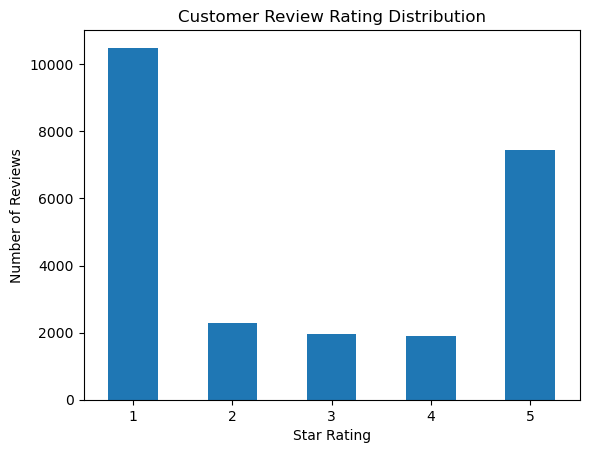

In [35]:
import matplotlib.pyplot as plt

rating_counts.plot(kind="bar")

plt.title("Customer Review Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## 21. Rule-Based Identification of Critical Reviews

The assessment requires critical reviews to be identified without using
Machine Learning.

For this project, a simple rule-based approach is used:

- Rating 1 → Critical
- Rating 2 → Critical
- Rating 3, 4, or 5 → Not classified as critical

This rule allows us to isolate customers who gave the lowest ratings
and are therefore more likely to have serious complaints.

In [36]:
# Identify critical reviews using the assessment's rule:
# reviews with a rating of 1 or 2 are classified as critical.
critical_reviews = clean_df[
    clean_df["star_rating"] <= 2
].copy()

# Display the number of critical reviews
critical_reviews.shape

(12796, 13)

## 22. Prepare Critical Review Text for Keyword Analysis

The critical reviews identified in the previous section are used for
complaint keyword analysis.

Only the cleaned review text from 1-star and 2-star reviews is considered.
This allows us to focus specifically on the problems reported by customers
who gave the lowest ratings.

In [37]:
# Select the cleaned review text from all critical reviews.
# Critical reviews were already identified using the 1-star and 2-star rule.

critical_text = critical_reviews["clean_review"]

# Display a few critical reviews to verify the text that will be analyzed.
critical_text.head()


0    frequent breakups and late alerts useless for now
1    there is little to no point in the app there i...
5                                    bad does not work
6    again latest update once again has info from o...
9    i own a 2014 rav this app is completely worthl...
Name: clean_review, dtype: object

## 23. Tokenize Critical Reviews

To identify common complaint keywords, each critical review is divided
into individual words.

The words from all critical reviews are then combined into one collection
so that their frequencies can be counted.

In [38]:
# Create an empty list to store words from all critical reviews.
all_words = []

# Process each critical review one by one.
for review in critical_text:
    
    # Split the cleaned review into individual words.
    words = review.split()
    
    # Add the words from the current review to the main word list.
    all_words.extend(words)

# Display the total number of words collected.
len(all_words)

451519

## 24. Count Word Frequencies

Python's `Counter` from the `collections` module is used to count how many
times each word appears across the critical reviews.

This follows the assessment requirement to use basic Python string
processing and `Counter` for identifying common complaint keywords.

In [39]:
# Count how frequently each word appears in the critical reviews.
word_counts = Counter(all_words)

# Display the 30 most frequently occurring words.
word_counts.most_common(30)

[('the', 21313),
 ('to', 15852),
 ('app', 13145),
 ('i', 11216),
 ('it', 10504),
 ('and', 10144),
 ('is', 7453),
 ('a', 7266),
 ('my', 6511),
 ('this', 5892),
 ('not', 5736),
 ('for', 5426),
 ('of', 4491),
 ('in', 4429),
 ('car', 4371),
 ('on', 3533),
 ('have', 3477),
 ('that', 3078),
 ('you', 3066),
 ('with', 2951),
 ('work', 2668),
 ('but', 2662),
 ('start', 2593),
 ('update', 2470),
 ('when', 2344),
 ('me', 2325),
 ('its', 2307),
 ('time', 2275),
 ('no', 2241),
 ('remote', 2163)]

## 25. Remove Common English Words

The initial word-frequency analysis contains common English words such as
"the", "and", "is", and "to".

These words do not represent meaningful customer complaints.

A manually defined list of common stopwords is therefore removed so that
the analysis focuses on meaningful words related to customer problems.

In [40]:
# Define common English words that do not provide useful complaint information.
stopwords = {
    "the", "and", "is", "to", "a", "of", "in", "it", "for", "on",
    "this", "that", "was", "with", "my", "i", "very", "but", "not",
    "have", "has", "had", "are", "be", "as", "an", "at", "or",
    "from", "app", "car", "its", "so", "they", "we", "you",
    "me", "your", "can", "will", "would", "been", "were", "all"
}

# Remove stopwords and very short words from the word list.
meaningful_words = [
    word for word in all_words
    if word not in stopwords and len(word) > 2
]

# Count the meaningful words.
complaint_word_counts = Counter(meaningful_words)

# Display the 30 most common meaningful words.
complaint_word_counts.most_common(30)

[('work', 2668),
 ('start', 2593),
 ('update', 2470),
 ('when', 2344),
 ('time', 2275),
 ('remote', 2163),
 ('cant', 2102),
 ('use', 2050),
 ('toyota', 2028),
 ('doesnt', 2023),
 ('even', 1881),
 ('now', 1845),
 ('get', 1751),
 ('just', 1716),
 ('vehicle', 1704),
 ('phone', 1702),
 ('after', 1547),
 ('connect', 1536),
 ('working', 1405),
 ('works', 1222),
 ('open', 1215),
 ('does', 1188),
 ('only', 1120),
 ('out', 1102),
 ('new', 1051),
 ('dont', 1002),
 ('service', 999),
 ('wont', 973),
 ('then', 968),
 ('still', 964)]

## 26. Top Complaint Keywords

The most frequent meaningful words from critical reviews are organized
into a table.

This provides a simple summary of the issues customers mention most
frequently in their negative feedback.

In [41]:
# Extract the 20 most frequently occurring meaningful words.
top_keywords = complaint_word_counts.most_common(20)

# Convert the results into a DataFrame for easier presentation.
keyword_df = pd.DataFrame(
    top_keywords,
    columns=["Keyword", "Frequency"]
)

keyword_df

,Keyword,Frequency
0,work,2668
1,start,2593
2,update,2470
3,when,2344
4,time,2275
5,remote,2163
6,cant,2102
7,use,2050
8,toyota,2028
9,doesnt,2023


## 27. Top Complaint Keywords Visualization

A bar chart is used to visualize the most frequently occurring keywords
in critical customer reviews.

This makes the main complaint themes easier to understand.

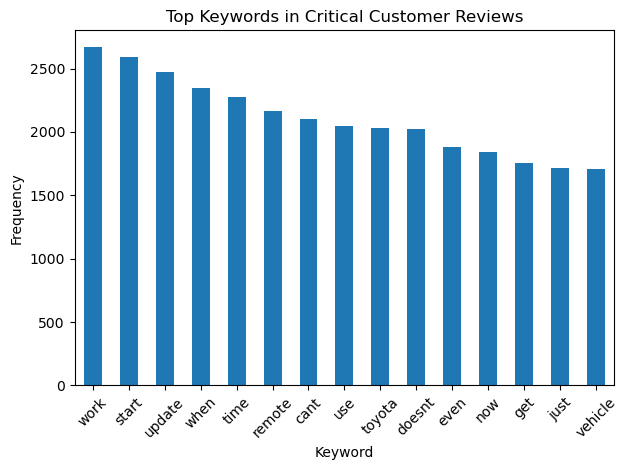

In [42]:
# Select the top 15 complaint-related keywords for visualization.
top_15 = keyword_df.head(15)

# Create a bar chart of keyword frequencies.
top_15.plot(
    x="Keyword",
    y="Frequency",
    kind="bar",
    legend=False
)

plt.title("Top Keywords in Critical Customer Reviews")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [43]:
complaint_word_counts.most_common(30)

[('work', 2668),
 ('start', 2593),
 ('update', 2470),
 ('when', 2344),
 ('time', 2275),
 ('remote', 2163),
 ('cant', 2102),
 ('use', 2050),
 ('toyota', 2028),
 ('doesnt', 2023),
 ('even', 1881),
 ('now', 1845),
 ('get', 1751),
 ('just', 1716),
 ('vehicle', 1704),
 ('phone', 1702),
 ('after', 1547),
 ('connect', 1536),
 ('working', 1405),
 ('works', 1222),
 ('open', 1215),
 ('does', 1188),
 ('only', 1120),
 ('out', 1102),
 ('new', 1051),
 ('dont', 1002),
 ('service', 999),
 ('wont', 973),
 ('then', 968),
 ('still', 964)]

## 28. Identify Candidate Reviews for Generative AI

The assessment requires three of the most critical and detailed negative
reviews to be processed by Generative AI.

To identify suitable candidates, we focus on 1-star and 2-star reviews
with sufficiently detailed review text.

Longer reviews are considered first because they usually contain more
information about the customer's specific problem.

In [44]:
# Select critical reviews that contain at least 50 characters.
# This removes extremely short reviews such as "bad" or "not working".
candidate_reviews = critical_reviews[
    critical_reviews["review_length"] >= 50
].copy()

# Sort candidates by rating first and review length second.
# A 1-star review is considered more critical than a 2-star review,
# while longer reviews are preferred within the same rating.
candidate_reviews = candidate_reviews.sort_values(
    by=["star_rating", "review_length"],
    ascending=[True, False]
)

# Display the top candidate reviews.
candidate_reviews[
    [
        "institution_name",
        "app_name",
        "star_rating",
        "review_length",
        "review_body"
    ]
].head(10)

,institution_name,app_name,star_rating,review_length,review_body
21670,Toyota,Toyota,1,1454,Issue: Randomly logged out since last use even...
21041,Toyota,Toyota,1,1181,"It's saved me a couple of times, telling me I'..."
23398,Lexus,Lexus,1,998,I bought a new ES in January. The dealer's tec...
22509,Toyota,Toyota,1,961,"As a Prius Prime (plug-in hybrid) owner, the m..."
20425,Toyota,Toyota,1,929,24/7 Battery Drain unless the app is force kil...
20942,Toyota,Toyota,1,926,I didn't realise how good the Entune app was u...
21591,Lexus,Lexus,1,914,The moment I start charging my cell into the U...
22650,Lexus,Lexus,1,867,Lexus has been at this for years and simply ca...
22798,Lexus,Lexus,1,827,I'm experiencing the same thing as others. I c...
22668,Lexus,Lexus,1,821,This app/service is all around frustrating. Th...


In [45]:
candidate_reviews[
    [
        "institution_name",
        "app_name",
        "star_rating",
        "review_length",
        "review_body"
    ]
].head(10)

,institution_name,app_name,star_rating,review_length,review_body
21670,Toyota,Toyota,1,1454,Issue: Randomly logged out since last use even...
21041,Toyota,Toyota,1,1181,"It's saved me a couple of times, telling me I'..."
23398,Lexus,Lexus,1,998,I bought a new ES in January. The dealer's tec...
22509,Toyota,Toyota,1,961,"As a Prius Prime (plug-in hybrid) owner, the m..."
20425,Toyota,Toyota,1,929,24/7 Battery Drain unless the app is force kil...
20942,Toyota,Toyota,1,926,I didn't realise how good the Entune app was u...
21591,Lexus,Lexus,1,914,The moment I start charging my cell into the U...
22650,Lexus,Lexus,1,867,Lexus has been at this for years and simply ca...
22798,Lexus,Lexus,1,827,I'm experiencing the same thing as others. I c...
22668,Lexus,Lexus,1,821,This app/service is all around frustrating. Th...


## 27. Refine Complaint Keywords

The initial word-frequency analysis contains both meaningful complaint terms
and general conversational words.

To make the results more useful, additional common words and conversational
terms are removed.

The goal is to retain words that provide useful information about the
customer's problem with the connected-car application.

In [46]:
# Add additional common conversational words that are not useful
# for identifying specific customer complaints.
additional_stopwords = {
    "when", "time", "use", "get", "just", "even", "now", "does",
    "only", "out", "new", "then", "still", "start", "after",
    "dont", "cant", "doesnt", "wont", "work", "works", "working",
    "thing", "things", "really", "also", "one", "much", "make",
    "made", "got", "going", "want", "need", "know", "see"
}

# Combine the original stopwords with the additional stopwords.
final_stopwords = stopwords.union(additional_stopwords)

# Keep meaningful words that are not in the final stopword list.
final_keywords = [
    word for word in all_words
    if word not in final_stopwords and len(word) > 2
]

# Count the refined keywords.
final_keyword_counts = Counter(final_keywords)

# Display the top 30 refined keywords.
final_keyword_counts.most_common(30)

[('update', 2470),
 ('remote', 2163),
 ('toyota', 2028),
 ('vehicle', 1704),
 ('phone', 1702),
 ('connect', 1536),
 ('open', 1215),
 ('service', 999),
 ('never', 934),
 ('pay', 896),
 ('times', 891),
 ('like', 878),
 ('lexus', 867),
 ('useless', 814),
 ('what', 808),
 ('features', 793),
 ('please', 775),
 ('fix', 769),
 ('since', 761),
 ('subscription', 755),
 ('there', 748),
 ('apps', 743),
 ('every', 723),
 ('more', 723),
 ('why', 704),
 ('should', 698),
 ('able', 687),
 ('because', 678),
 ('screen', 678),
 ('worked', 676)]

## 28. Final Complaint Keyword Table

The refined keyword frequencies are converted into a DataFrame.

This table represents the most frequently occurring meaningful terms
within the critical customer reviews.

In [47]:
# Get the 20 most common refined complaint-related keywords.
top_keywords = final_keyword_counts.most_common(20)

# Convert the keyword frequencies into a DataFrame.
keyword_df = pd.DataFrame(
    top_keywords,
    columns=["Keyword", "Frequency"]
)

# Display the final complaint keyword table.
keyword_df

,Keyword,Frequency
0,update,2470
1,remote,2163
2,toyota,2028
3,vehicle,1704
4,phone,1702
5,connect,1536
6,open,1215
7,service,999
8,never,934
9,pay,896


## 29. Visualization of Complaint Keywords

A bar chart is used to visualize the most frequent complaint-related
keywords found in critical customer reviews.

This provides an easy-to-understand view of the major issues mentioned
by customers.

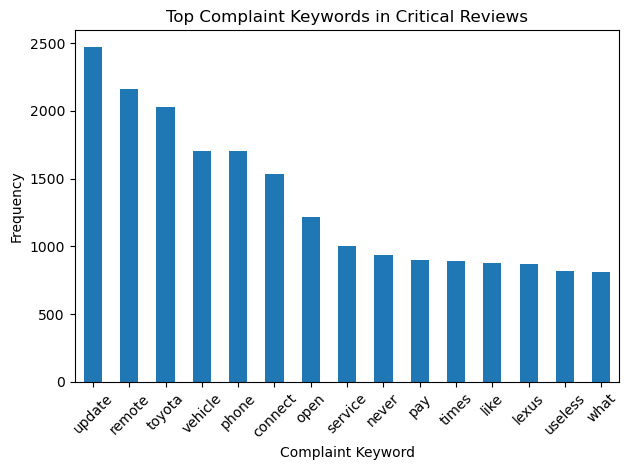

In [48]:
# Select the top 15 keywords for visualization.
top_15_keywords = keyword_df.head(15)

# Create a bar chart showing keyword frequencies.
top_15_keywords.plot(
    x="Keyword",
    y="Frequency",
    kind="bar",
    legend=False
)

plt.title("Top Complaint Keywords in Critical Reviews")
plt.xlabel("Complaint Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 30. Review Candidate Selection

The assessment requires three of the most critical and detailed negative
reviews.

The candidate reviews are displayed in full so that the actual customer
complaints can be reviewed before selecting the final three cases.

The selection will prioritize:

1. Very low rating, especially 1 star.
2. Detailed review content.
3. A clear and specific customer problem.
4. A complaint that can be addressed with a personalized response.

In [49]:
# Display the first 10 candidate reviews with their complete text.
for index, row in candidate_reviews.head(10).iterrows():
    
    print("=" * 100)
    print("INDEX:", index)
    print("COMPANY:", row["institution_name"])
    print("APP:", row["app_name"])
    print("RATING:", row["star_rating"])
    print("REVIEW LENGTH:", row["review_length"])
    print("\nCUSTOMER REVIEW:")
    print(row["review_body"])
    print()

INDEX: 21670
COMPANY: Toyota
APP: Toyota
RATING: 1
REVIEW LENGTH: 1454

CUSTOMER REVIEW:
Issue: Randomly logged out since last use even though it is supposed to keep me signed in. Attempt to login with biometric but some sort of login authentication bug. App hangs. Close app. Try again. Same thing. Repeat a few times while checking out at store or trying to finish some other task. Stop what I'm doing to try tapping in my login email and password instead. App hangs. Close app. Try again. This time it spins on logging in for a few minutes. Finally have access to app! Scroll and press remote services start to pre-cool vehicle. App freezes for a few minutes. Finally returns error that the climate control system could not be started, please check vehicle communication status. This is secret code that I forgot to lock my doors because this is required for remote starting. Exit app, because door lock/unlock feature is not inside the app but instead requires a press/hold of the app button on m

In [50]:
# Display the first 10 candidate reviews with their complete text.
# This allows us to read the full customer complaints before selecting
# the final three reviews for the Generative AI stage.

for index, row in candidate_reviews.head(10).iterrows():
    
    print("=" * 100)
    print("INDEX:", index)
    print("COMPANY:", row["institution_name"])
    print("APP:", row["app_name"])
    print("RATING:", row["star_rating"])
    print("REVIEW LENGTH:", row["review_length"])
    
    print("\nCUSTOMER REVIEW:")
    print(row["review_body"])
    print()

INDEX: 21670
COMPANY: Toyota
APP: Toyota
RATING: 1
REVIEW LENGTH: 1454

CUSTOMER REVIEW:
Issue: Randomly logged out since last use even though it is supposed to keep me signed in. Attempt to login with biometric but some sort of login authentication bug. App hangs. Close app. Try again. Same thing. Repeat a few times while checking out at store or trying to finish some other task. Stop what I'm doing to try tapping in my login email and password instead. App hangs. Close app. Try again. This time it spins on logging in for a few minutes. Finally have access to app! Scroll and press remote services start to pre-cool vehicle. App freezes for a few minutes. Finally returns error that the climate control system could not be started, please check vehicle communication status. This is secret code that I forgot to lock my doors because this is required for remote starting. Exit app, because door lock/unlock feature is not inside the app but instead requires a press/hold of the app button on m

## 31. Final Selection of Three Critical Reviews

Three critical reviews are selected for the Generative AI stage.

The selection is based on the following criteria:

1. The review has a 1-star rating and is therefore classified as critical.
2. The review is sufficiently detailed.
3. The review describes a specific customer problem.
4. The problem can be addressed through a personalized customer-support response.
5. The three selected reviews represent different types of connected-car
   application problems.

The selected reviews cover:
- Login and remote vehicle-function problems.
- Incorrect or outdated vehicle information.
- Battery drain and application performance problems.

In [51]:
# Define the indexes of the three selected critical reviews.
# These indexes were identified after reviewing the detailed candidate reviews.

selected_indices = [21670, 23398, 20425]

# Create a new DataFrame containing only the three selected reviews.
selected_reviews = clean_df.loc[selected_indices].copy()

# Display the selected reviews with the most important information.
selected_reviews[
    [
        "institution_name",
        "app_name",
        "star_rating",
        "review_length",
        "review_body"
    ]
]

,institution_name,app_name,star_rating,review_length,review_body
21670,Toyota,Toyota,1,1454,Issue: Randomly logged out since last use even...
23398,Lexus,Lexus,1,998,I bought a new ES in January. The dealer's tec...
20425,Toyota,Toyota,1,929,24/7 Battery Drain unless the app is force kil...


## 32. Selected Critical Review Details

The three selected reviews are displayed below for final verification
before sending them to the Generative AI model.

These reviews will be used as the input cases for generating personalized
customer-support responses.

In [52]:
# Display each selected review separately for easy verification.

for index, row in selected_reviews.iterrows():
    
    print("=" * 100)
    print("INDEX:", index)
    print("COMPANY:", row["institution_name"])
    print("APP:", row["app_name"])
    print("RATING:", row["star_rating"])
    print("REVIEW LENGTH:", row["review_length"])
    
    print("\nCUSTOMER REVIEW:")
    print(row["review_body"])
    
    print()

INDEX: 21670
COMPANY: Toyota
APP: Toyota
RATING: 1
REVIEW LENGTH: 1454

CUSTOMER REVIEW:
Issue: Randomly logged out since last use even though it is supposed to keep me signed in. Attempt to login with biometric but some sort of login authentication bug. App hangs. Close app. Try again. Same thing. Repeat a few times while checking out at store or trying to finish some other task. Stop what I'm doing to try tapping in my login email and password instead. App hangs. Close app. Try again. This time it spins on logging in for a few minutes. Finally have access to app! Scroll and press remote services start to pre-cool vehicle. App freezes for a few minutes. Finally returns error that the climate control system could not be started, please check vehicle communication status. This is secret code that I forgot to lock my doors because this is required for remote starting. Exit app, because door lock/unlock feature is not inside the app but instead requires a press/hold of the app button on m

## 33. Assign Complaint Categories

To make the selected complaints easier to interpret, each review is assigned
a simple complaint category based on the main issue described in the review.

This is a rule-based categorization and does not use Machine Learning.

The categories will also help us create more targeted prompts for the
Generative AI response stage.

In [53]:
# Assign a complaint category to each selected review.
# The categories are based on the main problem described in each review.

complaint_categories = {
    21670: "Login and Remote Vehicle Functions",
    23398: "Incorrect or Outdated Vehicle Data",
    20425: "Battery Drain and App Performance"
}

# Add the complaint category to the selected review DataFrame.
selected_reviews["complaint_category"] = selected_reviews.index.map(
    complaint_categories
)

# Display the final selected-review summary.
selected_reviews[
    [
        "institution_name",
        "app_name",
        "star_rating",
        "complaint_category"
    ]
]

,institution_name,app_name,star_rating,complaint_category
21670,Toyota,Toyota,1,Login and Remote Vehicle Functions
23398,Lexus,Lexus,1,Incorrect or Outdated Vehicle Data
20425,Toyota,Toyota,1,Battery Drain and App Performance


## 34. Generative AI Setup

The Generative AI stage uses the Google Gemini API to generate personalized
responses to the three selected critical customer reviews.

Each review will be provided to the model together with instructions to:

- Acknowledge the customer's specific problem.
- Show empathy.
- Apologize for the inconvenience.
- Address the actual complaint.
- Provide a professional response.
- Avoid making unsupported promises or guarantees.

In [54]:
!pip install -q google-genai

## 35. Import the Gemini Client

The Google GenAI Python library is imported so that the notebook can
communicate with the Gemini Generative AI API.

In [55]:
from google import genai

In [56]:
import os

# Ask for the API key when the notebook is executed
os.environ["GEMINI_API_KEY"] = input("Enter your Gemini API key: ")

# Create the Gemini client
client = genai.Client(
    api_key=os.environ["GEMINI_API_KEY"]
)

Enter your Gemini API key:  AQ.Ab8RN6IA2pYKC1nzhbWx6CLJb1neUxZVpiG6v8B2mrv5ReP2LQ


## 36. Test the Generative AI Connection

Before processing the customer reviews, a simple test request is sent to
Gemini to verify that the API connection is working correctly.

This prevents errors later when generating the three customer responses.

In [57]:
# Test Gemini API connection using the current Interactions API

response = client.interactions.create(
    model="gemini-3.8-flash",
    input="Reply with exactly: Gemini connection successful."
)

print(response.output_text)

Gemini connection successful.


In [58]:
# Test Gemini API connection using the current Interactions API

response = client.interactions.create(
    model="gemini-3.8-flash",
    input="Reply with exactly: Gemini connection successful."
)

print(response.output_text)

Gemini connection successful.


## 37. Customer Response Prompt

A structured prompt is used to ensure that the generated response is
personalized to the customer's actual complaint.

The model is instructed to acknowledge the problem, apologize, demonstrate
empathy, and avoid unsupported promises.

The prompt is reused for all three selected reviews while the actual
customer review and complaint category are dynamically inserted.

In [59]:
def create_customer_prompt(company, app, category, review):
    """
    Create a structured prompt for generating a customer-support response.

    Parameters:
    company   : Automotive company name
    app       : Connected-car application name
    category  : Main complaint category
    review    : Original customer review

    Returns:
    A prompt string containing the customer's specific complaint.
    """

    prompt = f"""
You are a professional customer-support representative for {company}.

A customer has submitted a 1-star review about the {app} connected-car app.

Complaint category:
{category}

Customer review:
{review}

Write a short, professional, personalized, and empathetic customer-support
response.

The response must:
1. Acknowledge the customer's specific problem.
2. Apologize for the inconvenience.
3. Show genuine empathy.
4. Address the actual issue mentioned by the customer.
5. Be professional and concise.
6. Avoid inventing refunds, compensation, technical fixes, or guarantees.
7. Do not claim that the issue has already been resolved.
8. Encourage the customer to contact the appropriate support channel if
   further assistance is required.

Return only the customer-support response.
"""

    return prompt

In [60]:
# Select the first review for testing the prompt and Gemini response.

review_1 = selected_reviews.loc[21670]

# Create the prompt using the actual customer information.
prompt_1 = create_customer_prompt(
    company=review_1["institution_name"],
    app=review_1["app_name"],
    category=review_1["complaint_category"],
    review=review_1["review_body"]
)

# Display the prompt so we can verify what will be sent to Gemini.
print(prompt_1)


You are a professional customer-support representative for Toyota.

A customer has submitted a 1-star review about the Toyota connected-car app.

Complaint category:
Login and Remote Vehicle Functions

Customer review:
Issue: Randomly logged out since last use even though it is supposed to keep me signed in. Attempt to login with biometric but some sort of login authentication bug. App hangs. Close app. Try again. Same thing. Repeat a few times while checking out at store or trying to finish some other task. Stop what I'm doing to try tapping in my login email and password instead. App hangs. Close app. Try again. This time it spins on logging in for a few minutes. Finally have access to app! Scroll and press remote services start to pre-cool vehicle. App freezes for a few minutes. Finally returns error that the climate control system could not be started, please check vehicle communication status. This is secret code that I forgot to lock my doors because this is required for remote 

In [61]:
# Send the first selected customer complaint to Gemini
# using the Interactions API.

response_1 = client.interactions.create(
    model="gemini-3.8-flash",
    input=prompt_1
)

# Display the generated customer-support response
print(response_1.output_text)

Thank you for taking the time to share your feedback, and please accept our sincere apologies for your frustrating experience with the Toyota app. We completely understand how aggravating it is to deal with unexpected logouts, biometric login freezes, and remote start failures—especially when you are simply trying to cool down your vehicle on a hot day. 

Your concerns regarding login stability and the Android remote door lock and climate control errors are very important to us. We want to ensure your connected services perform reliably. 

To help us investigate your specific vehicle profile and app setup, please reach out directly to our Toyota Brand Engagement Center at 1-800-331-4331 or select the "Help & Support" option within the app. A representative will be glad to assist you.


In [62]:
# Select the second critical review

review_2 = selected_reviews.loc[23398]

# Create the personalized prompt for the second review

prompt_2 = create_customer_prompt(
    company=review_2["institution_name"],
    app=review_2["app_name"],
    category=review_2["complaint_category"],
    review=review_2["review_body"]
)

# Display the prompt for verification
print(prompt_2)


You are a professional customer-support representative for Lexus.

A customer has submitted a 1-star review about the Lexus connected-car app.

Complaint category:
Incorrect or Outdated Vehicle Data

Customer review:
I bought a new ES in January. The dealer's tech expert tried off and on for a week to get the app communicating with my car, to the point they gave me a loaner car to give him time to work on it with the Lexus people. They finally got it registered, but it still does not work properly. Some data is correct, others haven't been updated in 2 weeks.Remote access may or may not be available at any given time. The "distance to empty" has been stuck on 101 for that time. It correctly shows that tire pressure is at 35, yet a message pops up that one or more tires is critically low. At one point it said I had driven the car 16.7 million miles! I cleared the cache, the data, and reinstalled the app -- nothing helps. It's a bit ironic that a builder of quality cars cannot get their

In [63]:
# Send the second customer complaint to Gemini

response_2 = client.interactions.create(
    model="gemini-3.8-flash",
    input=prompt_2
)

# Display the generated customer-support response
print(response_2.output_text)

Thank you for sharing your feedback, and we sincerely apologize for the frustration you have experienced with your new ES. We understand how disappointing it is to encounter erratic vehicle data—such as incorrect tire alerts, a frozen distance-to-empty reading, and inaccurate mileage—especially after the time you and your dealer have already spent trying to resolve this. We also deeply regret the runaround you experienced when calling our support line; this falls short of the seamless experience you rightfully expect from Lexus. 

To ensure this is properly escalated, we encourage you to contact our dedicated Lexus Connected Services team directly at 1-800-255-3987 (and specify "Connected Services" when prompted) or submit an inquiry through the "Help" section within the app. This will connect you with a specialized agent who can review your vehicle's telematics communication directly and assist in addressing these persistent data issues.


In [64]:
# Select the third critical review

review_3 = selected_reviews.loc[20425]

# Create the personalized prompt for the third review

prompt_3 = create_customer_prompt(
    company=review_3["institution_name"],
    app=review_3["app_name"],
    category=review_3["complaint_category"],
    review=review_3["review_body"]
)

# Display the prompt for verification
print(prompt_3)


You are a professional customer-support representative for Toyota.

A customer has submitted a 1-star review about the Toyota connected-car app.

Complaint category:
Battery Drain and App Performance

Customer review:
24/7 Battery Drain unless the app is force killed. "Closing" the app is not sufficient, must be force killed or it will drain the battery down to 20% (from a full charge) overnight, every night. Constant 24/7 CPU usage keeps my pants nice and warm unless the app is force killed after every use. Always #1 in "Apps with high battery usage or frequent crashes", and reported battery consumption. Takes more presses to get to the same information. Shows less information (windows/doors). Defies common UX expectations (cannot click on Tire Pressure to to get Tire Pressure, must click elsewhere). The previous app kinda sucked. How you made the new one *worse* blows my mind. It STILL puts up a non-removable, notsatifiable notification flag that says "Ready To Connect" even when co

In [65]:
# Send the third customer complaint to Gemini

response_3 = client.interactions.create(
    model="gemini-3.8-flash",
    input=prompt_3
)

# Display the generated customer-support response
print(response_3.output_text)

Hello, thank you for taking the time to share your detailed feedback. We sincerely apologize for the frustration you’ve experienced with the Toyota app. We understand how disruptive it is to deal with severe overnight battery drain, the need to constantly force-close the app, and an ongoing "Ready to Connect" notification, alongside a frustrating navigation experience. 

We take reports regarding high background CPU usage and performance issues very seriously, and your comments regarding the interface and battery consumption have been shared directly with our app development team. 

To help us take a closer look at your specific device and vehicle configuration, please reach out to our Toyota Brand Engagement Center at 1-800-331-4331 or contact us through the app’s support section so we can assist you further.


In [66]:
# Create a final DataFrame containing the 3 selected reviews
# and their AI-generated customer-support responses.

final_results = selected_reviews[
    [
        "institution_name",
        "app_name",
        "star_rating",
        "complaint_category",
        "review_body"
    ]
].copy()

# Add the Gemini-generated responses
final_results["ai_customer_response"] = [
    response_1.output_text,
    response_2.output_text,
    response_3.output_text
]

# Display the final results
final_results

,institution_name,app_name,star_rating,complaint_category,review_body,ai_customer_response
21670,Toyota,Toyota,1,Login and Remote Vehicle Functions,Issue: Randomly logged out since last use even...,Thank you for taking the time to share your fe...
23398,Lexus,Lexus,1,Incorrect or Outdated Vehicle Data,I bought a new ES in January. The dealer's tec...,"Thank you for sharing your feedback, and we si..."
20425,Toyota,Toyota,1,Battery Drain and App Performance,24/7 Battery Drain unless the app is force kil...,"Hello, thank you for taking the time to share ..."


In [67]:
# Check the final output structure

print("Number of selected reviews:", len(final_results))
print("Number of columns:", len(final_results.columns))

final_results.columns

Number of selected reviews: 3
Number of columns: 6


Index(['institution_name', 'app_name', 'star_rating', 'complaint_category',
       'review_body', 'ai_customer_response'],
      dtype='object')

In [68]:
# Save the final results containing the 3 selected reviews
# and their Gemini-generated customer responses.

final_results.to_csv(
    "final_customer_responses.csv",
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!


In [69]:
# Read the saved file again to verify that it was saved correctly.

check_results = pd.read_csv("final_customer_responses.csv")

print("File loaded successfully!")
print("Rows:", check_results.shape[0])
print("Columns:", check_results.shape[1])

check_results.head()

File loaded successfully!
Rows: 3
Columns: 6


,institution_name,app_name,star_rating,complaint_category,review_body,ai_customer_response
0,Toyota,Toyota,1,Login and Remote Vehicle Functions,Issue: Randomly logged out since last use even...,Thank you for taking the time to share your fe...
1,Lexus,Lexus,1,Incorrect or Outdated Vehicle Data,I bought a new ES in January. The dealer's tec...,"Thank you for sharing your feedback, and we si..."
2,Toyota,Toyota,1,Battery Drain and App Performance,24/7 Battery Drain unless the app is force kil...,"Hello, thank you for taking the time to share ..."


In [70]:
# Save the final results as an Excel file.

final_results.to_excel(
    "final_customer_responses.xlsx",
    index=False
)

print("Excel file saved successfully!")

Excel file saved successfully!


## 9. Final Insights

The analysis of customer reviews from connected-car applications revealed
several important customer pain points.

The rule-based filtering identified 1-star and 2-star reviews as critical
reviews. Detailed critical reviews were then selected for Generative AI
response generation.

The selected reviews highlighted issues related to:
- Login and remote vehicle functions
- Incorrect or outdated vehicle information
- Battery drain and application performance

Generative AI was then used to create personalized and empathetic
customer-support responses for the selected complaints.

In [71]:
# Display a summary of the selected critical reviews

final_results[
    [
        "institution_name",
        "app_name",
        "star_rating",
        "complaint_category"
    ]
]

,institution_name,app_name,star_rating,complaint_category
21670,Toyota,Toyota,1,Login and Remote Vehicle Functions
23398,Lexus,Lexus,1,Incorrect or Outdated Vehicle Data
20425,Toyota,Toyota,1,Battery Drain and App Performance


### Key Findings

1. A large number of reviews were classified as critical using the
   rule-based condition of star rating <= 2.

2. Customers reported problems with important connected-car features,
   including login, remote vehicle controls, vehicle information, and
   application performance.

3. Some reviews described multiple problems in a single review, showing
   that customer complaints can involve both technical and usability issues.

4. Generative AI successfully converted the selected detailed complaints
   into personalized customer-support responses.

5. The prompt instructed the AI to acknowledge the complaint, apologize,
   show empathy, address the specific issue, and avoid unsupported promises.

## 10. Conclusion

This project demonstrated how Python, Pandas, rule-based text analysis,
and Generative AI can be combined to analyze customer feedback.

The dataset was cleaned by handling missing values and standardizing
review text. Critical reviews were identified using a simple rule-based
approach based on star ratings. Complaint keywords were analyzed to
understand common customer issues.

Three detailed critical reviews were selected and processed using the
Gemini Generative AI API. Personalized and empathetic customer-support
responses were generated for each selected complaint.

The project demonstrates a practical workflow for converting raw customer
feedback into useful insights and automated customer-support responses.

In [72]:
%%writefile README.md

# Customer Review Analysis and Generative AI Response System

## 1. Project Overview

This project analyzes customer reviews from connected-car mobile applications
using Python and Pandas.

The project identifies critical customer reviews using a rule-based approach
and analyzes common complaint keywords. Three detailed critical reviews are
then selected and processed using the Gemini Generative AI API to generate
personalized and empathetic customer-support responses.

---

## 2. Objectives

The main objectives of this project are:

- Load and understand a customer-review dataset.
- Clean and preprocess customer review text.
- Handle missing values.
- Analyze customer ratings.
- Identify critical reviews using a rule-based approach.
- Identify common complaint keywords.
- Select three detailed critical reviews.
- Use Generative AI to generate personalized customer responses.
- Save the final AI-generated responses for further use.

---

## 3. Dataset

### Dataset Name

OEM Connected-Car App Reviews Dataset:
Google Play User Feedback from 21 Automotive Companion Apps

### Source

Mendeley Data

### DOI

10.17632/fsrgtm6vf7.1

### Dataset Description

The dataset contains customer reviews of automotive connected-car
applications collected from Google Play.

The dataset contains review information such as:

- Institution/company
- Application name
- Review text
- Star rating
- Thumbs-up count
- Review date
- Application version
- Language

---

## 4. Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Collections / Counter
- Google Gemini API
- Google GenAI Python SDK
- Jupyter Notebook

---

## 5. Data Cleaning

A working copy of the original dataset was created so that the original
data remained unchanged.

The following cleaning steps were performed:

1. Empty review-title information was removed because the column contained
   no useful values.

2. Missing application-version values were replaced with "Unknown".

3. Review text was converted to lowercase.

4. Special characters and unnecessary non-alphanumeric characters were
   removed.

5. Extra spaces were removed from the review text.

6. A cleaned review column named `clean_review` was created.

7. Review length was calculated using the cleaned review text.

---

## 6. Exploratory Data Analysis

The following analysis was performed:

- Dataset dimensions
- Column names
- Dataset information
- Missing-value analysis
- Rating distribution
- Rating percentages
- Rating summary
- Review-length analysis
- Rating visualization

The dataset contains 24,103 customer reviews.

The rating distribution was:

- 1 Star: 10,494
- 2 Stars: 2,302
- 3 Stars: 1,960
- 4 Stars: 1,895
- 5 Stars: 7,452

---

## 7. Rule-Based Critical Review Identification

A simple rule-based approach was used instead of machine learning.

Reviews with a star rating less than or equal to 2 were classified as
critical reviews.

The rule used was:

    star_rating <= 2

This identified 12,796 critical reviews.

This approach makes the selection logic simple, transparent, and easy to
understand.

---

## 8. Complaint Keyword Analysis

The cleaned text from critical reviews was analyzed using Python string
processing and `collections.Counter`.

Common words and complaint-related terms were counted to understand the
issues frequently mentioned by customers.

The keyword analysis helps identify recurring problems in the customer
feedback without using a machine-learning model.

---

## 9. Selection of Critical Reviews

Three detailed 1-star reviews were selected for Generative AI processing.

The selected reviews were:

| Review Index | Company | Complaint Category |
|---|---|---|
| 21670 | Toyota | Login and Remote Vehicle Functions |
| 23398 | Lexus | Incorrect or Outdated Vehicle Data |
| 20425 | Toyota | Battery Drain and App Performance |

The reviews were selected based on:

- Very low star rating
- Detailed review content
- Clearly identifiable customer problems
- Different complaint categories

---

## 10. Generative AI Implementation

Google Gemini was used to generate personalized customer-support responses.

The Gemini API was connected using the Google GenAI Python SDK.

The prompt was designed to instruct the model to:

- Acknowledge the customer's specific problem.
- Apologize for the inconvenience.
- Show empathy.
- Address the actual complaint.
- Keep the response professional and concise.
- Avoid unsupported promises.
- Avoid claiming that the issue has already been resolved.
- Recommend contacting an appropriate support channel when further help
  is required.

The same prompt structure was reused for all three reviews while the
company, application, complaint category, and customer review were
inserted dynamically.

---

## 11. API Key Setup

The Gemini API key is required to run the Generative AI section.

The API key should NOT be stored directly in the notebook or uploaded to
GitHub.

The notebook uses an environment variable to provide the API key.

Example:

    import os
    from google import genai

    os.environ["GEMINI_API_KEY"] = input("Enter your Gemini API key: ")

    client = genai.Client(
        api_key=os.environ["GEMINI_API_KEY"]
    )

Never share your API key publicly.

---

## 12. Gemini Model

The project uses the Gemini model:

    gemini-3.8-flash

The Generative AI request is made using the Interactions API.

Example:

    response = client.interactions.create(
        model="gemini-3.8-flash",
        input=prompt
    )

    print(response.output_text)

---

## 13. Final Results

The final output contains:

- Company name
- Application name
- Star rating
- Complaint category
- Original customer review
- AI-generated customer-support response

The final results contain three selected customer reviews and their
corresponding AI-generated responses.

---

## 14. Output Files

The project generates the following output files:

- `final_customer_responses.csv`
- `final_customer_responses.xlsx`

These files contain the final selected reviews and the corresponding
Generative AI customer-support responses.

---

## 15. How to Run the Project

### Step 1

Install the required Python libraries.

### Step 2

Open the Jupyter Notebook.

### Step 3

Load the customer-review dataset.

### Step 4

Run the data cleaning and exploratory analysis sections.

### Step 5

Run the rule-based critical review filtering section.

### Step 6

Run the complaint keyword analysis.

### Step 7

Select the three detailed critical reviews.

### Step 8

Install and import the Google GenAI SDK.

### Step 9

Enter your Gemini API key when prompted.

### Step 10

Run the Generative AI sections to generate customer responses.

### Step 11

Run the final-results section.

### Step 12

The final CSV and Excel files will be generated.

---

## 16. Key Findings

The analysis identified a large number of low-rated customer reviews.

The selected detailed complaints showed issues involving:

- Login and authentication
- Remote vehicle functions
- Incorrect or outdated vehicle information
- Battery drain
- Application performance
- Navigation and usability

Generative AI was able to convert the selected complaints into
personalized and empathetic customer-support responses.

---

## 17. Conclusion

This project demonstrates a practical workflow for analyzing customer
feedback using Python and Generative AI.

Python and Pandas were used for data cleaning and analysis. A transparent
rule-based approach was used to identify critical reviews, while keyword
analysis helped identify common complaint themes.

Three detailed critical reviews were then processed using the Gemini API
to generate personalized customer-support responses.

The project demonstrates how traditional data analysis and Generative AI
can be combined to transform raw customer feedback into useful insights
and automated support responses.

---

## 18. Future Enhancements

Possible future improvements include:

- Sentiment analysis of all customer reviews.
- Automatic complaint-category classification.
- Dashboard creation using Power BI.
- Automated response generation for a larger number of reviews.
- Multilingual customer-support responses.
- Integration with a customer-support system.
- Monitoring customer complaints over time.

Writing README.md


In [73]:
os.environ["GEMINI_API_KEY"] = input("Enter your Gemini API key: ")

Enter your Gemini API key:  AQ.Ab8RN6IA2pYKC1nzhbWx6CLJb1neUxZVpiG6v8B2mrv5ReP2LQ


In [74]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
C:\Users\SUHAS

Files in this folder:
['-1.14-windows.xml', '.anaconda', '.conda', '.continuum', '.copilot', '.dwagent', '.ipynb_checkpoints', '.ipython', '.junie', '.jupyter', '.matplotlib', '.ms-ad', '.ollama', '.openjfx', '.virtual_documents', '.vscode', '.vscode-shared', '12345.csv', 'anaconda3', 'anupama.ipynb', 'AppData', 'Application Data', 'august1.ipynb', 'august11_pandas.ipynb', 'august14_data visualization.ipynb', 'august20.ipynb', 'august25.ipynb', 'august4.ipynb', 'august5.ipynb', 'august6.ipynb', 'Car details v3.csv', 'chocolate_slr.csv', 'Contacts', 'Cookies', 'dataset.xlsx', 'Data_Cleaning_pandas.ipynb', 'details.csv', 'Downloads', 'Favorites', 'final_customer_responses.csv', 'final_customer_responses.xlsx', 'health_insurance.csv', 'Hotel_Bookings_Regression.ipynb', 'hotel_bookings_revenue.csv', 'IntelGraphicsProfiles', 'july30.ipynb', 'launchpad31.ipynb', 'Linear_Regression_SLR_MLR.ipynb', 'Links', 'Local Settings', 'log.txt', 'market_sales_LMS.csv', 'M

In [75]:
import os

files_needed = [
    "README.md",
    "final_customer_responses.csv",
    "final_customer_responses.xlsx",
    "dataset.xlsx"
]

for file in files_needed:
    if os.path.exists(file):
        print("✅ Found:", file)
    else:
        print("❌ Missing:", file)

✅ Found: README.md
✅ Found: final_customer_responses.csv
✅ Found: final_customer_responses.xlsx
✅ Found: dataset.xlsx


In [76]:
os.getcwd()

'C:\\Users\\SUHAS'

In [77]:
with open("README.md", "r", encoding="utf-8") as f:
    print(f.read())


# Customer Review Analysis and Generative AI Response System

## 1. Project Overview

This project analyzes customer reviews from connected-car mobile applications
using Python and Pandas.

The project identifies critical customer reviews using a rule-based approach
and analyzes common complaint keywords. Three detailed critical reviews are
then selected and processed using the Gemini Generative AI API to generate
personalized and empathetic customer-support responses.

---

## 2. Objectives

The main objectives of this project are:

- Load and understand a customer-review dataset.
- Clean and preprocess customer review text.
- Handle missing values.
- Analyze customer ratings.
- Identify critical reviews using a rule-based approach.
- Identify common complaint keywords.
- Select three detailed critical reviews.
- Use Generative AI to generate personalized customer responses.
- Save the final AI-generated responses for further use.

---

## 3. Dataset

### Dataset Name

OEM Connected-

In [78]:
final_results.to_csv(
    "final_customer_responses.csv",
    index=False
)

In [79]:
final_results.to_excel(
    "final_customer_responses.xlsx",
    index=False
)